# S1-3 債券価格とYTM（価格⇔利回り）

## 学習目標

- 固定利付債の価格式を、将来キャッシュフローの割引の合計として導出できる
- 最終利回り（YTM）の定義と、その裏にある前提・限界を説明できる
- 価格-利回り曲線が凸である理由と、デュレーション近似のずれを結びつけられる
- パー債・プレミアム債・ディスカウント債を、クーポンとYTMの大小で判別できる
- 市場慣行の periodic exponent（次クーポンまでの残期間割合 $w$、$j$ 番目の割引指数 $w+j$）を明示して価格関数を実装できる
- Newton法とBrent法でYTMを逆算し、それぞれの収束条件と失敗ケースを言える
- 日本の単利（単利最終利回り）慣行と複利YTMの差を数値で示せる

## 実務での位置づけ（ファンドはどう稼ぐか）

価格とYTMの相互変換は、債券デスクで最も頻繁に叩く計算です。セルサイドのマーケットメイカーは在庫を抱えながら買値と売値を提示し、その差で稼ぎますが、顧客からの引き合い（RFQ）はしばしば「利回りで何ぼ」で来て、約定と受渡は価格で行います。この価格⇔利回りの往復を機械精度・ミリ秒単位で回せなければ、両面クォートを継続的に出し続けるマーケットメイクは成立しません。

相対価値ファンドにとって、YTM は銘柄間の割高・割安を横並びで比べるための共通言語です。年限も表面利率も違う銘柄を同じ土俵に載せ、フィット済みカーブからの乖離（rich/cheap）を測って平均回帰に賭けます。ここで価格-利回り曲線が凸である（コンベキシティ）性質を理解していないと、利回りだけを見て「割安」と判断したのに、価格変動の非対称性で思わぬ損を出します。凸性は、大きな金利変動局面ではロング側に有利に働くため、キャリーと合わせて収益源にもなります。

求解手法（Newton法・Brent法）の収束条件を押さえることは、単なる数値計算の話ではなく運用の信頼性に直結します。深いディスカウント債やコールオプション付き債では初期値次第で解が飛ぶことがあり、自動値付けシステムが誤った利回りを返せば、その価格で約定した瞬間に損失が確定します。さらに日本国債の単利最終利回り慣行と複利YTMの差を数値で押さえておかないと、国内債と海外債を同じ尺度で比較したつもりが、市場慣行の違いによる見かけの差を実力差と誤認します。この価格式が無ければ、評価・リスク・裁定のどれも始まりません。


## 理論

### キャッシュフローの割引から価格式を導く

固定利付債は、あらかじめ決まった日に一定額のクーポンを払い、満期に額面を
償還する契約である。年間利払回数を $f$、年クーポン率を $c$、額面を $F$ とすると、
1回のクーポンは $C = F\,c/f$ である。将来の各キャッシュフロー $c_j$ を、
同一の利回り $y$（$f$ 回複利）で現在価値に割り引き、その総和を価格とみなす。

決済日がちょうどクーポン日に一致する（端数期間がない）単純な場合、残り $n$ 回の
キャッシュフローに対する価格は次式になる。

$$
P = \sum_{k=1}^{n} \frac{c_k}{\left(1 + y/f\right)^{k}}
  = \sum_{k=1}^{n-1} \frac{C}{\left(1 + y/f\right)^{k}}
    + \frac{C + F}{\left(1 + y/f\right)^{n}}
$$

第1項はクーポンの等比数列、第2項は額面償還の割引である。これは「将来の
現金は同じ利回りで割り引く」という一物一価の考え方をそのまま式にしたもので、
割引係数 $DF_k = (1+y/f)^{-k}$ の線形結合になっている。

### 端数期間と street convention の periodic exponent

実務では決済日はクーポン日の中間にあることが普通で、そのとき指数を整数から
実数へずらす。市場慣行（street convention）では、次クーポンまでの残期間を
期間全体で割った割合

$$
w = \frac{\mathrm{yf}(\text{settlement},\ \text{next})}
         {\mathrm{yf}(\text{prev},\ \text{next})}
$$

を端数指数として使う。ここで $\mathrm{yf}$ は day count 規約（S1-2）に基づく
年数である。次クーポン（$j=0$）の割引指数を $w$ とし、以降のクーポンは
整数を1ずつ足して $w+j$ とする。つまり価格（経過利子込みの dirty price）は

$$
P_{\text{dirty}} = \sum_{j=0}^{n-1}
  \frac{c_j}{\left(1 + y/f\right)^{w+j}}
$$

となる。端数は最初のクーポンまでの $w$ にだけ現れ、以降のクーポン間隔は
指数 1 きざみで数える点が要である。この数え方が QuantLib の複利利回りと
一致し、`bondlab.bond` もこの規約で実装されている。

### 経過利子と clean / dirty price

直前クーポン日から決済日までの期間に応じて、買い手は経過利子（accrued
interest）を売り手に払う。

$$
A = C \cdot \frac{\mathrm{yf}(\text{prev},\ \text{settlement})}
                 {\mathrm{yf}(\text{prev},\ \text{next})}
$$

市場で気配される清算価格（clean price）は、この経過利子を除いた値である。

$$
P_{\text{clean}} = P_{\text{dirty}} - A
$$

### 最終利回り（YTM）の意味と限界

最終利回り（YTM, yield to maturity）は、価格式を価格に一致させる唯一の $y$、
すなわち $P_{\text{dirty}}(y) = P_{\text{market,dirty}}$ の解である。これは
将来キャッシュフロー列に対する内部収益率（IRR）であり、次の前提が満たされる
ときにだけ「満期まで持ったときの年率リターン」と一致する。

1. 満期まで保有する
2. すべてのクーポンを同じ利回り $y$ で再投資できる
3. 途中でデフォルトしない

現実にはクーポン再投資レートは時々の市場金利で変動するため、YTM は
実現リターンそのものではなく、フラットな割引率という近似指標である。
また複数のキャッシュフローを1つの $y$ で割り引くため、年限ごとに異なる
ゼロレート（S2）を1本に押し込めた要約値でもある。

### ゼロクーポン債との関係

クーポンがゼロ（$C=0$）で満期に額面だけを払う債券をゼロクーポン債と呼ぶ。
キャッシュフローが1本なので価格式は

$$
P = \frac{F}{\left(1 + y/f\right)^{w}}
$$

となり、価格と利回りが1対1で解析的に対応する。利付債は複数のゼロクーポン債の
束とみなせて、YTM はその束を代表する平均的な利回りに相当する。

### パー・プレミアム・ディスカウント債

クーポン率と YTM の大小関係で、清算価格が額面（パー）に対しどちら側に来るかが
決まる。

| 関係 | 呼称 | clean price |
|---|---|---|
| $c > y$ | プレミアム債 | 額面より高い（$>100$） |
| $c = y$ | パー債 | 額面ちょうど（$=100$） |
| $c < y$ | ディスカウント債 | 額面より低い（$<100$） |

クーポンが市場の要求利回りより高ければ、その上乗せ分を価格が織り込んで
額面超えになる、という直感で理解できる。

### 価格-利回り曲線と凸性

価格は $y$ の減少関数である（$\partial P/\partial y < 0$）。さらに二階微分が
正なので、曲線は下に凸（convex）である。

$$
\frac{\partial^2 P}{\partial y^2}
  = \sum_{j} \frac{(w+j)(w+j+1)}{f^2}
    \frac{c_j}{\left(1+y/f\right)^{w+j+2}} > 0
$$

凸性（convexity）があるため、利回りが同じ幅だけ上下しても価格の動きは
対称ではない。利回り低下による値上がりの方が、利回り上昇による値下がりより
大きい。デュレーション（S1-4）は曲線の接線（一次近似）なので、利回り変化が
大きいほど接線は実際の曲線より下にずれ、値下がりを過大・値上がりを過小に
見積もる。このずれの主要項が凸性である。

### 日本の単利利回り慣行

日本の個人向け国債や店頭表示では、複利の YTM ではなく単利最終利回り
（単利, simple yield）が使われることがある。残存年数 $T$、クーポン $c$（％表示なら
額面あたり金額 $C_{\%}$）、価格 $P$、額面 $100$ に対して

$$
y_{\text{simple}}
  = \frac{C_{\%} + \dfrac{100 - P}{T}}{P}
$$

で定義する。年あたりのクーポン収入と、満期償還までの値上がり（値下がり）を
単純に年割りしてから価格で割った値で、複利効果を考慮しない。複利 YTM とは
一般に一致せず、ディスカウント債では単利利回りの方が高めに出やすい。

## スクラッチ実装

価格関数と YTM ソルバー（Newton法・Brent法）を自作し、`bondlab.bond` と
一致するかを確認する。端数指数は前節の street convention に従い、$w+j$ で
数える。day count の年数計算だけは S1-2 の `bondlab.daycount.year_fraction`
を借りる（規約の詳細はそちらで扱った）。

### 使用する自作関数

| 関数 | 引数 | 返り値 | 役割 |
|---|---|---|---|
| `add_months(d, months)` | 日付, 加算月数 | 日付 | 月末丸め付きで月を加減する |
| `coupon_schedule(issue, maturity, freq)` | 発行日, 満期, 年利払回数 | 日付リスト | 満期から逆算した利払日列 |
| `cashflows(schedule, coupon, freq, face)` | 利払日列, クーポン率, 頻度, 額面 | `(日付, 金額)` のリスト | クーポン列＋満期の額面償還 |
| `surrounding(issue, schedule, settlement)` | 発行日, 利払日列, 決済日 | `(直前日, 次回日)` | 決済日を挟むクーポン日 |
| `dirty_price(flows, ytm, freq, prev, nxt, settlement, conv)` | CF, 利回り, 頻度, 直前日, 次回日, 決済日, 規約 | 価格 | $w+j$ 割引で dirty price |
| `accrued(coupon, freq, face, prev, nxt, settlement, conv)` | クーポン率, 頻度, 額面, 直前日, 次回日, 決済日, 規約 | 経過利子 | 直前クーポンからの按分 |
| `price_and_deriv(...)` | dirty_price と同じ | `(価格, dP/dy)` | Newton 用に価格と一階微分を返す |
| `ytm_newton(target, freq, ..., guess)` | 目標 dirty, 頻度, ほか, 初期値 | 利回り | Newton法でYTMを解く |
| `ytm_brent(target, freq, ..., a, b)` | 目標 dirty, 頻度, ほか, 区間 | 利回り | Brent法でYTMを解く |

In [1]:
import datetime as dt

import numpy as np

import bondlab
from bondlab import bond as blbond
from bondlab import daycount

np.random.seed(0)
print("bondlab version:", bondlab.__version__)


def add_months(d: dt.date, months: int) -> dt.date:
    """月を加減する。月末は各月の末日に丸める。"""
    m0 = d.month - 1 + months
    y = d.year + m0 // 12
    m = m0 % 12 + 1
    if m == 12:
        last = 31
    else:
        last = (dt.date(y, m + 1, 1) - dt.timedelta(days=1)).day
    return dt.date(y, m, min(d.day, last))


def coupon_schedule(issue: dt.date, maturity: dt.date, freq: int):
    """満期から逆算してクーポン日を刻み、発行日より後の日付だけ返す。"""
    step = 12 // freq
    dates = [maturity]
    d = maturity
    while d > issue:
        d = add_months(d, -step)
        dates.append(d)
    dates = sorted(set(dates))
    return [x for x in dates if x > issue]


def cashflows(schedule, coupon: float, freq: int, face: float = 100.0):
    """クーポン列に、満期の額面償還を上乗せした (日付, 金額) のリスト。"""
    cpn = face * coupon / freq
    flows = [(d, cpn) for d in schedule]
    d_last, c_last = flows[-1]
    flows[-1] = (d_last, c_last + face)
    return flows


def surrounding(issue: dt.date, schedule, settlement: dt.date):
    """決済日を挟む (直前クーポン日, 次クーポン日) を返す。"""
    all_dates = [issue] + list(schedule)
    prev = nxt = None
    for d in all_dates:
        if d <= settlement:
            prev = d
        elif nxt is None:
            nxt = d
    return prev, nxt


def dirty_price(flows, ytm, freq, prev, nxt, settlement, conv):
    """street convention の w+j 割引で dirty price を求める。"""
    full = daycount.year_fraction(prev, nxt, conv)
    rem = daycount.year_fraction(settlement, nxt, conv)
    w = rem / full if full > 0 else 0.0
    future = [(d, c) for d, c in flows if d > settlement]
    pv = 0.0
    for j, (_d, c) in enumerate(future):
        pv += c * (1.0 + ytm / freq) ** (-(w + j))
    return pv


def accrued(coupon, freq, face, prev, nxt, settlement, conv):
    """直前クーポン日から決済日までを規約年数で按分した経過利子。"""
    full = daycount.year_fraction(prev, nxt, conv)
    part = daycount.year_fraction(prev, settlement, conv)
    cpn = face * coupon / freq
    return cpn * (part / full) if full > 0 else 0.0

bondlab version: 0.0.1


価格関数が用意できたので、Newton法のために価格と一階微分 $\partial P/\partial y$ を
同時に返す関数を書く。微分は
$\partial P/\partial y = \sum_j c_j\,\dfrac{-(w+j)}{f}\,(1+y/f)^{-(w+j+1)}$
を解析的に評価する。

In [2]:
def price_and_deriv(flows, ytm, freq, prev, nxt, settlement, conv):
    """(dirty price, dP/dy) を返す。Newton法の反復に使う。"""
    full = daycount.year_fraction(prev, nxt, conv)
    rem = daycount.year_fraction(settlement, nxt, conv)
    w = rem / full if full > 0 else 0.0
    future = [(d, c) for d, c in flows if d > settlement]
    base = 1.0 + ytm / freq
    price = 0.0
    deriv = 0.0
    for j, (_d, c) in enumerate(future):
        expo = w + j
        price += c * base ** (-expo)
        deriv += c * (-expo / freq) * base ** (-(expo + 1.0))
    return price, deriv


def ytm_newton(target, freq, flows, prev, nxt, settlement, conv,
               guess=0.03, tol=1e-12, maxiter=100):
    """Newton法で dirty price = target を満たす利回りを解く。"""
    y = guess
    for _ in range(maxiter):
        price, deriv = price_and_deriv(flows, y, freq, prev, nxt, settlement, conv)
        diff = price - target
        if abs(diff) < tol:
            return y
        if deriv == 0.0:
            raise ZeroDivisionError("微分がゼロで更新できません")
        y = y - diff / deriv
    return y


def ytm_brent(target, freq, flows, prev, nxt, settlement, conv,
              a=-0.5, b=2.0, tol=1e-14, maxiter=200):
    """Brent法（逆二次補間＋二分法）で dirty price = target を解く。"""
    def g(y):
        return dirty_price(flows, y, freq, prev, nxt, settlement, conv) - target

    fa, fb = g(a), g(b)
    if fa * fb > 0:
        raise ValueError("区間 [a, b] で符号が変わりません（根を挟めない）")
    if abs(fa) < abs(fb):
        a, b = b, a
        fa, fb = fb, fa
    c, fc = a, fa
    mflag = True
    d = a
    for _ in range(maxiter):
        if fb == 0 or abs(b - a) < tol:
            return b
        if fa != fc and fb != fc:
            # 逆二次補間
            s = (a * fb * fc / ((fa - fb) * (fa - fc))
                 + b * fa * fc / ((fb - fa) * (fb - fc))
                 + c * fa * fb / ((fc - fa) * (fc - fb)))
        else:
            # 割線法
            s = b - fb * (b - a) / (fb - fa)
        cond = (not (min((3 * a + b) / 4, b) < s < max((3 * a + b) / 4, b))
                or (mflag and abs(s - b) >= abs(b - c) / 2)
                or (not mflag and abs(s - b) >= abs(c - d) / 2)
                or (mflag and abs(b - c) < tol)
                or (not mflag and abs(c - d) < tol))
        if cond:
            s = (a + b) / 2  # 二分法へフォールバック
            mflag = True
        else:
            mflag = False
        fs = g(s)
        d, c, fc = c, b, fb
        if fa * fs < 0:
            b, fb = s, fs
        else:
            a, fa = s, fs
        if abs(fa) < abs(fb):
            a, b = b, a
            fa, fb = fb, fa
    return b

自作の価格・ソルバーを、`blbond.FixedRateBond` と突き合わせる。
半年利払・クーポン2%・満期2029年6月15日の債券を、決済日2026年9月10日・
利回り2.5%で評価する。

In [3]:
issue = dt.date(2024, 6, 15)
maturity = dt.date(2029, 6, 15)
coupon = 0.02
freq = 2
conv = "ACT/ACT"
settlement = dt.date(2026, 9, 10)
y = 0.025

sched = coupon_schedule(issue, maturity, freq)
flows = cashflows(sched, coupon, freq)
prev, nxt = surrounding(issue, sched, settlement)

scratch_dirty = dirty_price(flows, y, freq, prev, nxt, settlement, conv)
scratch_accr = accrued(coupon, freq, 100.0, prev, nxt, settlement, conv)
scratch_clean = scratch_dirty - scratch_accr

blb = blbond.FixedRateBond(issue, maturity, coupon, freq, conv)
print(f"scratch dirty : {scratch_dirty:.10f}")
print(f"bondlab dirty : {blb.dirty_price(y, settlement):.10f}")
print(f"scratch clean : {scratch_clean:.10f}")
print(f"bondlab clean : {blb.clean_price(y, settlement):.10f}")
print(f"scratch accrued: {scratch_accr:.10f}")
print(f"bondlab accrued: {blb.accrued(settlement):.10f}")

assert abs(scratch_dirty - blb.dirty_price(y, settlement)) < 1e-10
assert abs(scratch_clean - blb.clean_price(y, settlement)) < 1e-10

scratch dirty : 99.1473149141
bondlab dirty : 99.1473149141
scratch clean : 98.6719050781
bondlab clean : 98.6719050781
scratch accrued: 0.4754098361
bondlab accrued: 0.4754098361


価格から利回りを逆算する向きも確認する。clean price を与え、まず dirty へ
戻してから Newton法・Brent法で解き、両者と `bondlab` の答えが一致するかを見る。

In [4]:
target_clean = scratch_clean
target_dirty = target_clean + scratch_accr

y_newton = ytm_newton(target_dirty, freq, flows, prev, nxt, settlement, conv, guess=0.03)
y_brent = ytm_brent(target_dirty, freq, flows, prev, nxt, settlement, conv)
y_bondlab = blb.yield_from_price(target_clean, settlement)

print(f"Newton法  : {y_newton:.12f}")
print(f"Brent法   : {y_brent:.12f}")
print(f"bondlab   : {y_bondlab:.12f}")
print(f"真の利回り: {y:.12f}")

assert abs(y_newton - y) < 1e-10
assert abs(y_brent - y) < 1e-10
assert abs(y_newton - y_bondlab) < 1e-10

Newton法  : 0.025000000000
Brent法   : 0.025000000000
bondlab   : 0.025000000000
真の利回り: 0.025000000000


### ソルバーの失敗ケース

Newton法は初期値と関数形に敏感である。価格-利回り関数はほぼ単調・凸なので
通常は数回で収束するが、極端な初期値では利回りが $-f$ 付近に飛び、$(1+y/f)$ が
0 以下になって発散しうる。一方 Brent法は根を挟む区間 $[a,b]$ さえ与えれば
二分法の保証で必ず収束するが、区間の両端で符号が変わっていなければ
そもそも開始できない。下では両者の性質を数値で示す。

In [5]:
# Newton法は妥当な初期値なら数反復で収束する。
for guess in (0.0, 0.01, 0.05, 0.10):
    yv = ytm_newton(target_dirty, freq, flows, prev, nxt, settlement, conv, guess=guess)
    print(f"初期値 {guess:.2f} → 収束値 {yv:.10f}")

# Brent法は符号が変わらない区間では根を挟めず、明示的に失敗する。
try:
    ytm_brent(target_dirty, freq, flows, prev, nxt, settlement, conv, a=0.10, b=0.50)
except ValueError as err:
    print("Brent法の区間不正:", err)

初期値 0.00 → 収束値 0.0250000000
初期値 0.01 → 収束値 0.0250000000
初期値 0.05 → 収束値 0.0250000000
初期値 0.10 → 収束値 0.0250000000
Brent法の区間不正: 区間 [a, b] で符号が変わりません（根を挟めない）


## QuantLib検証

QuantLib の `FixedRateBond` と突合する。`bondlab` の ACT/ACT は債券の ISMA/Bond
変種に対応するため、`ql.ActualActual(ql.ActualActual.Bond, schedule)` を使う。
これで clean price は機械精度（$\sim 10^{-13}$）で一致する。

In [6]:
import QuantLib as ql

ql_sched = ql.Schedule(
    ql.Date(15, 6, 2024), ql.Date(15, 6, 2029),
    ql.Period(ql.Semiannual), ql.NullCalendar(),
    ql.Unadjusted, ql.Unadjusted,
    ql.DateGeneration.Backward, False,
)
ql_dc = ql.ActualActual(ql.ActualActual.Bond, ql_sched)
qlb = ql.FixedRateBond(0, 100.0, ql_sched, [0.02], ql_dc)

d = ql.Date(10, 9, 2026)
ql.Settings.instance().evaluationDate = d
ir = ql.InterestRate(0.025, ql_dc, ql.Compounded, ql.Semiannual)

ql_clean = ql.BondFunctions.cleanPrice(qlb, ir, d)
ql_accrued = qlb.accruedAmount(d)
print(f"QuantLib clean  : {ql_clean:.12f}")
print(f"scratch  clean  : {scratch_clean:.12f}")
print(f"clean 差        : {abs(ql_clean - scratch_clean):.2e}")
print(f"QuantLib accrued: {ql_accrued:.12f}")
print(f"scratch  accrued: {scratch_accr:.12f}")

assert abs(ql_clean - scratch_clean) < 1e-9

QuantLib clean  : 98.671905078064
scratch  clean  : 98.671905078064
clean 差        : 2.84e-14
QuantLib accrued: 0.475409836066
scratch  accrued: 0.475409836066


利回り逆算も QuantLib と突き合わせる。`BondPrice` を渡す
`BondFunctions.bondYield` を使い、自作 Newton法の解と比較する。

In [7]:
bp = ql.BondPrice(ql_clean, ql.BondPrice.Clean)
ql_yield = ql.BondFunctions.bondYield(qlb, bp, ql_dc, ql.Compounded, ql.Semiannual, d)
print(f"QuantLib bondYield: {ql_yield:.10f}")
print(f"scratch  Newton   : {y_newton:.10f}")
print(f"差               : {abs(ql_yield - y_newton):.2e}")

assert abs(ql_yield - y_newton) < 1e-7

QuantLib bondYield: 0.0250000001
scratch  Newton   : 0.0250000000
差               : 5.18e-11


## 実データ適用

ネットワークを使わず、現実的なクーポン・満期を持つ合成の実在風 JGB を3本
構築し、市場の clean price から YTM を逆算する。決済日は2026年9月10日で統一する。
3本は年限（5年・10年・20年）と、パー債・ディスカウント債・プレミアム債を
意図的に混ぜている。

In [8]:
import pandas as pd

settle = dt.date(2026, 9, 10)

universe = [
    # 名称, 発行日, 満期, クーポン, 市場clean
    ("JGB 5年 (低クーポン)", dt.date(2024, 6, 20), dt.date(2029, 6, 20), 0.004, 99.10),
    ("JGB 10年 (中期)", dt.date(2023, 9, 20), dt.date(2033, 9, 20), 0.008, 97.50),
    ("JGB 20年 (高クーポン)", dt.date(2020, 6, 20), dt.date(2040, 6, 20), 0.015, 101.20),
]

rows = []
for name, iss, mat, cpn, mkt_clean in universe:
    sc = coupon_schedule(iss, mat, 2)
    fl = cashflows(sc, cpn, 2)
    pv, nx = surrounding(iss, sc, settle)
    accr = accrued(cpn, 2, 100.0, pv, nx, settle, "ACT/ACT")
    tgt_dirty = mkt_clean + accr
    ytm_scratch = ytm_brent(tgt_dirty, 2, fl, pv, nx, settle, "ACT/ACT")
    bb = blbond.FixedRateBond(iss, mat, cpn, 2, "ACT/ACT")
    ytm_bl = bb.yield_from_price(mkt_clean, settle)
    # 残存年数（単利利回り用）
    T = daycount.year_fraction(settle, mat, "ACT/365F")
    simple = (cpn * 100.0 + (100.0 - mkt_clean) / T) / mkt_clean
    kind = "プレミアム" if cpn > ytm_scratch else ("ディスカウント" if cpn < ytm_scratch else "パー")
    rows.append({
        "銘柄": name,
        "クーポン%": cpn * 100,
        "市場clean": mkt_clean,
        "経過利子": round(accr, 4),
        "複利YTM%": round(ytm_scratch * 100, 4),
        "bondlab YTM%": round(ytm_bl * 100, 4),
        "単利利回り%": round(simple * 100, 4),
        "区分": kind,
    })

result = pd.DataFrame(rows)
display(result)

# scratch と bondlab の YTM が一致することを確認。
for r in rows:
    assert abs(r["複利YTM%"] - r["bondlab YTM%"]) < 1e-3

,銘柄,クーポン%,市場clean,経過利子,複利YTM%,bondlab YTM%,単利利回り%,区分
0,JGB 5年 (低クーポン),0.4,99.1,0.0896,0.7281,0.7281,0.7305,ディスカウント
1,JGB 10年 (中期),0.8,97.5,0.3783,1.1716,1.1716,1.1851,ディスカウント
2,JGB 20年 (高クーポン),1.5,101.2,0.3361,1.4038,1.4038,1.3962,プレミアム


クーポンと複利 YTM の大小がそのまま区分（プレミアム／ディスカウント）に対応し、
単利利回りは複利 YTM とわずかにずれる。ディスカウント債（市場価格 < 100）では
満期償還益を単純に年割りする単利のほうが高めに出やすい。

### 価格-利回り曲線の可視化

10年債について、利回りを振って clean price を計算し、価格-利回り曲線の凸性を
描く。あわせて、ある基準利回りでの接線（デュレーションに相当する一次近似）を
重ね、利回りが大きく動くほど接線が曲線から離れる様子を見る。

findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


...

findfont: Font family 'Meiryo' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


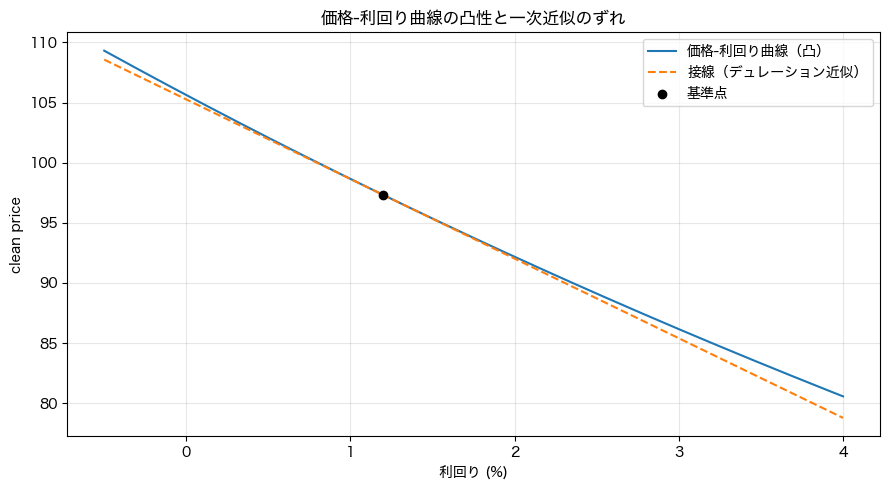

In [9]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = ["Hiragino Sans", "Yu Gothic", "Meiryo", "IPAexGothic", "Noto Sans CJK JP", "Arial Unicode MS", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
name, iss, mat, cpn, _ = universe[1]
sc = coupon_schedule(iss, mat, 2)
fl = cashflows(sc, cpn, 2)
pv, nx = surrounding(iss, sc, settle)
accr10 = accrued(cpn, 2, 100.0, pv, nx, settle, "ACT/ACT")


def clean_of(yv):
    return dirty_price(fl, yv, 2, pv, nx, settle, "ACT/ACT") - accr10


ys = np.linspace(-0.005, 0.04, 200)
prices = np.array([clean_of(v) for v in ys])

y0 = 0.012
p0, dp = price_and_deriv(fl, y0, 2, pv, nx, settle, "ACT/ACT")
p0_clean = p0 - accr10
tangent = p0_clean + dp * (ys - y0)  # 一次近似（接線）

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(ys * 100, prices, label="価格-利回り曲線（凸）")
ax.plot(ys * 100, tangent, "--", label="接線（デュレーション近似）")
ax.scatter([y0 * 100], [p0_clean], color="k", zorder=5, label="基準点")
ax.set_xlabel("利回り (%)")
ax.set_ylabel("clean price")
ax.set_title("価格-利回り曲線の凸性と一次近似のずれ")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

実線（真の価格）は破線（接線）より常に上側にある。これが凸性で、利回りが
基準から離れるほどずれが広がる。一次近似は値上がりを過小・値下がりを過大に
見積もり、その差の主要項が凸性（S1-4 のコンベクシティ）である。

## 演習

1. 上の3銘柄について、市場 clean price から複利 YTM と単利最終利回りを
   再計算し、両者の差（bp）を求めよ。差の符号が銘柄ごとにどうなるかを、
   プレミアム／ディスカウントの区分と結びつけて説明せよ。ヒント：単利は
   複利効果と再投資を無視するため、価格が額面から離れるほど差が開く。
2. 10年債について、基準利回り 1.2% まわりで利回りを $\pm50$bp・$\pm200$bp
   動かしたときの「実際の価格変化」と「一次近似（接線）による価格変化」を
   表にまとめ、両者の食い違いを凸性で説明せよ。近似が過大評価になるのは
   値上がり側か値下がり側か、理由とともに述べよ。

解答例は `solutions/S1/sol_0103.py` に置く。

## 用語集

定義の正は `glossary/01_bond_basics.md`。ここでは初出語の一行要約のみ示す。

| 用語 | 英語 | 一行定義 |
|---|---|---|
| 最終利回り | yield to maturity (YTM) | 価格式を市場価格に一致させる割引率。将来CFに対する内部収益率 |
| パー債 | par bond | クーポン率と YTM が等しく、清算価格が額面ちょうどになる債券 |
| 単利利回り | simple yield | クーポンと償還損益を年割りし価格で割った、複利を考えない利回り |
| Newton法 | Newton's method | 価格と一階微分を使い接線で根を追う反復解法。初期値に敏感 |
| 凸性 | convexity | 価格-利回り曲線の下に凸な性質。一次近似のずれの主要項 |